# 25 June 2026
# Sapkas Michail
# Lunar Lander - Final Project for Deep Neural Networks

In [3]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Current device: {torch.cuda.get_device_name(0)}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

CUDA available: True
Current device: NVIDIA GeForce RTX 2060
Using device: cuda


In [ ]:
LATENT_DIM = 64
BURN_IN_LENGTH = 4
SEQUENCE_LENGTH = 16

LR_ACTOR = 1e-4
LR_CRITIC = 1e-3
BATCH_SIZE = 64

GAMMA = 0.99
TAU = 1.0
MIN_REPLAY_SIZE = 15_000
REPLAY_BUFFER_SIZE = 75_000
TRAIN_FREQ = 100

SIGMA_START = 1.0
SIGMA_DECAY = 0.998
SIGMA_MIN = 0.02

TOTAL_TIMESTEPS = 300_000
MAX_EPISODE_STEPS = 1000

In [9]:
def update_sigma_decay(sigma, total_steps_in_buffer, min_replay_size):
    if total_steps_in_buffer < min_replay_size:
        return sigma
    return max(SIGMA_MIN, sigma * SIGMA_DECAY)

# ==========================================
# NETWORK DEFINITIONS (State Dim augmented by 1 for Time Step Tracking)
# ==========================================
class RecurrentActor(nn.Module):
    def __init__(self, state_dim=9, action_dim=2, hidden_dim=LATENT_DIM): # 8 + 1 time feature
        super().__init__()
        self.gru = nn.GRU(state_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh() 
        )

    def forward(self, x, hidden_state=None):
        gru_out, hidden_state = self.gru(x, hidden_state)
        actions = self.fc_out(gru_out)
        return actions, hidden_state


class RecurrentCritic(nn.Module):
    def __init__(self, state_dim=9, action_dim=2, hidden_dim=LATENT_DIM): # 8 + 1 time feature
        super().__init__()
        self.gru = nn.GRU(state_dim + action_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, action, hidden_state=None):
        combined_features = torch.cat([x, action], dim=2)
        gru_out, hidden_state = self.gru(combined_features, hidden_state)
        q_values = self.fc_out(gru_out)
        return q_values, hidden_state


# Main Networks
actor = RecurrentActor().to(device)
critic = RecurrentCritic().to(device)

# Target Networks
actor_target = RecurrentActor().to(device)
critic_target = RecurrentCritic().to(device)
actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())
actor_target.eval()
critic_target.eval()

# Optimizers
actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)
loss_fn = nn.MSELoss()

In [10]:
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
current_episode_transitions = []
sigma = SIGMA_START

episode_rewards = []
moving_avg_rewards = []
current_episode_reward = 0
current_episode_length = 0

def sample_sequence_batch():
    batch_states, batch_actions, batch_rewards, batch_terminated = [], [], [], []
    batch_init_actor_hidden = []
    batch_init_critic_hidden = []
    
    sample_len = BURN_IN_LENGTH + SEQUENCE_LENGTH + 1
    valid_episodes = [ep for ep in replay_buffer if len(ep) >= sample_len]
    
    for _ in range(BATCH_SIZE):
        episode = random.choice(valid_episodes)
        start_idx = random.randint(0, len(episode) - sample_len)
        
        seq_states, seq_actions, seq_rewards, seq_terminated = [], [], [], []
        
        for i in range(sample_len):
            state, action, reward, _, terminated, _, saved_act_hid, saved_crit_hid = episode[start_idx + i]
            
            if i == 0:
                if saved_act_hid is not None:
                    init_act = saved_act_hid
                else:
                    init_act = np.zeros((1, 1, LATENT_DIM))
                batch_init_actor_hidden.append(init_act)
                
                if saved_crit_hid is not None:
                    init_crit = saved_crit_hid
                else:
                    init_crit = np.zeros((1, 1, LATENT_DIM))
                batch_init_critic_hidden.append(init_crit)
            
            seq_states.append(state)
            seq_actions.append(action)
            seq_rewards.append(reward)
            seq_terminated.append(terminated) # Track ground-truth environmental termination explicitly
            
        batch_states.append(seq_states)
        batch_actions.append(seq_actions)
        batch_rewards.append(seq_rewards)
        batch_terminated.append(seq_terminated)

    states_all = torch.FloatTensor(np.array(batch_states)).to(device)       
    actions_all = torch.FloatTensor(np.array(batch_actions)).to(device)  
    rewards_all = torch.FloatTensor(np.array(batch_rewards)).unsqueeze(-1).to(device) 
    terminated_all = torch.FloatTensor(np.array(batch_terminated)).unsqueeze(-1).to(device)     
    
    init_act_t = torch.FloatTensor(np.concatenate(batch_init_actor_hidden, axis=1)).to(device)
    init_crit_t = torch.FloatTensor(np.concatenate(batch_init_critic_hidden, axis=1)).to(device)
    
    return states_all, actions_all, rewards_all, terminated_all, init_act_t, init_crit_t

def train_step():
    states_all, actions_all, rewards_all, terminated_all, init_act, init_crit = sample_sequence_batch()
    
    actor.train()
    critic.train()

    # --- 1. BURN-IN PHASE ---
    if BURN_IN_LENGTH > 0:
        with torch.no_grad():
            burn_states = states_all[:, :BURN_IN_LENGTH, :]
            burn_actions = actions_all[:, :BURN_IN_LENGTH, :]
            
            _, act_hidden_warmed = actor(burn_states, init_act)
            _, act_target_hidden_warmed = actor_target(burn_states, init_act)
            
            _, crit_hidden_warmed = critic(burn_states, burn_actions, init_crit)
            _, crit_target_hidden_warmed = critic_target(burn_states, burn_actions, init_crit)
    else:
        act_hidden_warmed, act_target_hidden_warmed = init_act, init_act
        crit_hidden_warmed, crit_target_hidden_warmed = init_crit, init_crit

    # --- 2. TIMELINE SLICES ---
    start_idx = BURN_IN_LENGTH
    end_idx = BURN_IN_LENGTH + SEQUENCE_LENGTH
    
    states_t = states_all[:, start_idx:end_idx, :]
    actions_t = actions_all[:, start_idx:end_idx, :]
    rewards_t = rewards_all[:, start_idx:end_idx, :]
    terminated_t = terminated_all[:, start_idx:end_idx, :]
    
    next_states_t = states_all[:, (start_idx + 1):(end_idx + 1), :]

    # --- 3. CRITIC OPTIMIZATION WITH BOOTSTRAPPING FOR TRUNCATION ---
    with torch.no_grad():
        next_actions_t, _ = actor_target(next_states_t, act_target_hidden_warmed.detach())
        next_q_values, _ = critic_target(next_states_t, next_actions_t, crit_target_hidden_warmed.detach())
        # CRITICAL CHANGE: Only mask out future rewards if terminated_t is True. 
        # If truncated is true, terminated remains False, allowing proper infinite-horizon bootstrapping.
        target_q_values = rewards_t + (GAMMA * next_q_values * (1 - terminated_t))

    current_q_values, _ = critic(states_t, actions_t, crit_hidden_warmed.detach())
    critic_loss = loss_fn(current_q_values, target_q_values)
    
    critic_optimizer.zero_grad()
    critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(critic.parameters(), max_norm=10.0)
    critic_optimizer.step()

    # --- 4. ACTOR OPTIMIZATION ---
    predicted_actions, _ = actor(states_t, act_hidden_warmed.detach())
    actor_q_values, _ = critic(states_t, predicted_actions, crit_hidden_warmed.detach())
    actor_loss = -actor_q_values.mean()
    
    actor_optimizer.zero_grad()
    actor_loss.backward()
    torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=10.0)
    actor_optimizer.step()

    # --- 5. SOFT TARGET UPDATES ---
    with torch.no_grad():
        for param, target_param in zip(actor.parameters(), actor_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)
            
        for param, target_param in zip(critic.parameters(), critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)

# ==========================================
# ENVIRONMENT LOOP
# ==========================================
env = gym.make("LunarLander-v3", continuous=True)
observation, info = env.reset(seed=42)

actor_hidden = None 
critic_hidden = None

print("Initializing Recurrent DDPG training loop...", flush=True)
pbar = tqdm(range(TOTAL_TIMESTEPS), desc="Training", leave=True)

for step in pbar:
    total_steps_in_buffer = sum(len(ep) for ep in replay_buffer)
    
    # Structure state to append a normalized time signature tracking step progression
    time_feature = current_episode_length / MAX_EPISODE_STEPS
    augmented_observation = np.append(observation, time_feature)
    
    if total_steps_in_buffer < MIN_REPLAY_SIZE:
        action = env.action_space.sample()  
        state_tensor = torch.FloatTensor(augmented_observation).unsqueeze(0).unsqueeze(0).to(device)
        action_tensor = torch.FloatTensor(action).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            _, next_actor_hidden = actor(state_tensor, actor_hidden)
            _, next_critic_hidden = critic(state_tensor, action_tensor, critic_hidden)
    else:
        actor.eval()
        critic.eval()
        state_tensor = torch.FloatTensor(augmented_observation).unsqueeze(0).unsqueeze(0).to(device)
        
        with torch.no_grad():
            action_pred, next_actor_hidden = actor(state_tensor, actor_hidden)
            action = action_pred.squeeze(0).squeeze(0).cpu().numpy()
        
        action = action + np.random.normal(0, sigma, size=2)
        action = np.clip(action, -1.0, 1.0)
        
        action_tensor = torch.FloatTensor(action).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            _, next_critic_hidden = critic(state_tensor, action_tensor, critic_hidden)

    saved_act_hid = actor_hidden.detach().cpu().numpy() if actor_hidden is not None else None
    saved_crit_hid = critic_hidden.detach().cpu().numpy() if critic_hidden is not None else None

    next_observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
        
    current_episode_reward += reward
    current_episode_length += 1

    # Append next step time feature to next observation structure
    next_time_feature = current_episode_length / MAX_EPISODE_STEPS
    augmented_next_observation = np.append(next_observation, next_time_feature)

    # Store components, explicitly separating terminated and truncated signatures
    current_episode_transitions.append((
        augmented_observation, action, reward, augmented_next_observation, 
        terminated, truncated, saved_act_hid, saved_crit_hid
    ))
    
    observation = next_observation
    actor_hidden = next_actor_hidden
    critic_hidden = next_critic_hidden

    if total_steps_in_buffer >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
        train_step()

    if done:
        replay_buffer.append(current_episode_transitions)
        current_episode_transitions = []
        
        episode_rewards.append(current_episode_reward)
        avg_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) > 0 else 0
        moving_avg_rewards.append(avg_reward)

        status_msg = "Warming Up" if total_steps_in_buffer < MIN_REPLAY_SIZE else "Learning"

        if total_steps_in_buffer >= MIN_REPLAY_SIZE:
            sigma = update_sigma_decay(sigma, total_steps_in_buffer, MIN_REPLAY_SIZE)

        pbar.set_postfix({
            "Ep": len(episode_rewards),
            "Last_R": f"{current_episode_reward:.1f}",
            "100-Ep_Avg": f"{avg_reward:.1f}",
            "Sigma": f"{sigma:.3f}",
            "Mode": status_msg
        })

        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0
        actor_hidden = None
        critic_hidden = None

env.close()
print("\nTraining Complete!")

Initializing Recurrent DDPG training loop...


Training:   0%|          | 0/300000 [00:00<?, ?it/s]

Training:  87%|████████▋ | 261276/300000 [18:50<02:47, 231.10it/s, Ep=2204, Last_R=-171.9, 100-Ep_Avg=-146.3, Sigma=0.020, Mode=Learning]


KeyboardInterrupt: 

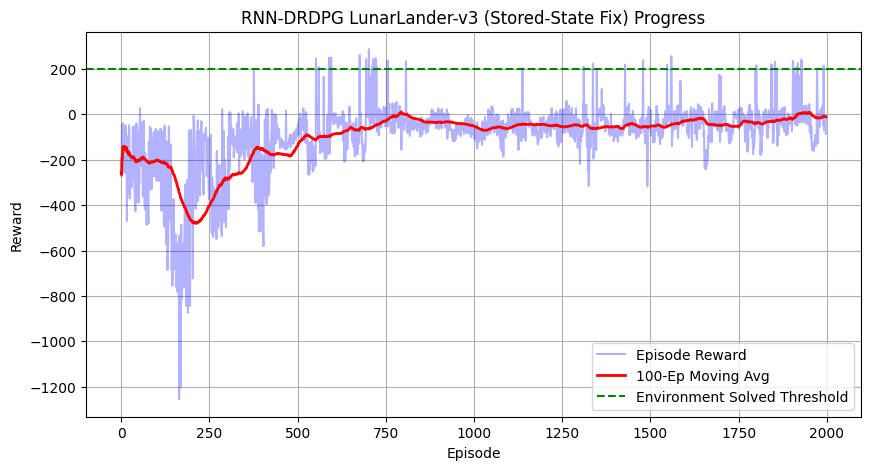

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("RNN-DRDPG LunarLander-v3 (Stored-State Fix) Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("rnn_drdpg_lunar_lander_progress.png")
plt.show()

In [18]:
# Save the trained model weights
torch.save(actor.state_dict(), "rnn_drdpg_lunar_lander.pth")
print("Model saved to rnn_drdpg_lunar_lander.pth")

Model saved to rnn_drdpg_lunar_lander.pth


In [7]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
import time

# Ensure device configuration matches your training environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters must match the training architecture changes
LATENT_DIM = 128
MAX_EPISODE_STEPS = 1000 

class RecurrentActor(nn.Module):
    def __init__(self, state_dim=9, action_dim=2, hidden_dim=LATENT_DIM): # 8 state variables + 1 time feature
        super().__init__()
        self.gru = nn.GRU(state_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh() 
        )

    def forward(self, x, hidden_state=None):
        gru_out, hidden_state = self.gru(x, hidden_state)
        actions = self.fc_out(gru_out)
        return actions, hidden_state

# Initialize and load the trained weights
actor_net = RecurrentActor().to(device)
actor_net.load_state_dict(torch.load("rnn_drdpg_lunar_lander.pth", map_location=device))
actor_net.eval()  # Set network to evaluation mode

# Initialize continuous environment with human rendering enabled
env = gym.make("LunarLander-v3", continuous=True, render_mode="human")

# Run for 5 demonstration episodes
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    current_episode_length = 0
    done = False
    
    # CRITICAL: Reset the recurrent hidden state at the start of every episode
    actor_hidden = None

    print(f"Starting Evaluation Episode {episode + 1}...")

    while not done:
        # 1. Structure state to append the normalized time signature tracking step progression
        time_feature = current_episode_length / MAX_EPISODE_STEPS
        augmented_observation = np.append(observation, time_feature)

        # 2. Convert augmented observation to tensor and reshape to (batch=1, seq_len=1, features=9)
        state_tensor = torch.FloatTensor(augmented_observation).unsqueeze(0).unsqueeze(0).to(device)

        # Always Exploit: Pass state and hidden_state into the Actor network
        with torch.no_grad():
            action_pred, next_actor_hidden = actor_net(state_tensor, actor_hidden)
            # Extract the raw continuous array values from the tensor
            action = action_pred.squeeze(0).squeeze(0).cpu().numpy()
            
        # Clamp actions to [-1.0, 1.0] as a safety guardrail for Gym boundaries
        action = np.clip(action, -1.0, 1.0)

        # Step the environment
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        
        # 3. Increment the step length counter to keep the time features synchronous
        current_episode_length += 1
        
        # Roll the hidden state forward for the next step
        actor_hidden = next_actor_hidden

        # Small sleep delay so the human eye can track the landing frame rate
        time.sleep(0.01)

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting Evaluation Episode 1...
Episode 1 Finished! Total Reward: -95.3

Starting Evaluation Episode 2...
Episode 2 Finished! Total Reward: -48.4

Starting Evaluation Episode 3...
Episode 3 Finished! Total Reward: -41.5

Starting Evaluation Episode 4...
Episode 4 Finished! Total Reward: 175.6

Starting Evaluation Episode 5...
Episode 5 Finished! Total Reward: -128.2

Evaluation Complete!
